In [1]:
# Part 2 of regression in python with statsmodel

In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

In [3]:
taiwan_df = pd.read_csv('Data/taiwan_realestate.csv')

taiwan_df.head()

,No,TransactionDate,HouseAge,DistanceToMRT,NumberConvenienceStores,Latitude,Longitude,PriceOfUnitArea
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
taiwan_df.isna().sum()

No                         0
TransactionDate            0
HouseAge                   0
DistanceToMRT              0
NumberConvenienceStores    0
Latitude                   0
Longitude                  0
PriceOfUnitArea            0
dtype: int64

**Parallel slopes linear regression:** there is one numeric explanatory variable and one categorical explanatory variable and it is called parallel slopes due to the shape of the predictions

In [5]:
import pandas as pd

# Create age categories
taiwan_df["HouseAge"] = pd.cut(
    taiwan_df["HouseAge"],
    bins=[0, 15, 30, 45],
    labels=[
        "house_age_years[0 to 15]",
        "house_age_years[15 to 30]",
        "house_age_years[30 to 45]"
    ],
    include_lowest=True
)

print(taiwan_df.head())

   No  TransactionDate                   HouseAge  DistanceToMRT  \
0   1         2012.917  house_age_years[30 to 45]       84.87882   
1   2         2012.917  house_age_years[15 to 30]      306.59470   
2   3         2013.583   house_age_years[0 to 15]      561.98450   
3   4         2013.500   house_age_years[0 to 15]      561.98450   
4   5         2012.833   house_age_years[0 to 15]      390.56840   

   NumberConvenienceStores  Latitude  Longitude  PriceOfUnitArea  
0                       10  24.98298  121.54024             37.9  
1                        9  24.98034  121.53951             42.2  
2                        5  24.98746  121.54391             47.3  
3                        5  24.98746  121.54391             54.8  
4                        5  24.97937  121.54245             43.1  


In [6]:
# Fit a linear regression of PriceOfUnitArea vs. NumberConvenienceStores
mdl_price_vs_conv = ols("PriceOfUnitArea ~ NumberConvenienceStores",
                        data=taiwan_df).fit()
print(mdl_price_vs_conv.params)

Intercept                  27.181105
NumberConvenienceStores     2.637653
dtype: float64


In [7]:
# Fit a linear regression of PriceOfUnitArea vs. HouseAge, no intercept
mdl_price_vs_age = ols("PriceOfUnitArea ~ HouseAge + 0", data=taiwan_df).fit()
print(mdl_price_vs_age.params)

HouseAge[house_age_years[0 to 15]]     41.619792
HouseAge[house_age_years[15 to 30]]    32.643750
HouseAge[house_age_years[30 to 45]]    37.812766
dtype: float64


In [8]:
# Fit a linear regression of PriceOfUnitArea vs. NumberConvenienceStores plus HouseAge, no intercept
mdl_price_vs_both = ols("PriceOfUnitArea ~ NumberConvenienceStores + HouseAge + 0", data=taiwan_df).fit()

# Print the coefficients
print(mdl_price_vs_both.params)

HouseAge[house_age_years[0 to 15]]     30.972185
HouseAge[house_age_years[15 to 30]]    23.444381
HouseAge[house_age_years[30 to 45]]    25.008209
NumberConvenienceStores                 2.610907
dtype: float64


For each additional nearby convenience store, the expected house price, in TWD per square meter, increases by 2.61.
For a house aged 0 to 15 years with zero nearby convenience stores, the expected house price is 30.97 TWD per square meter.

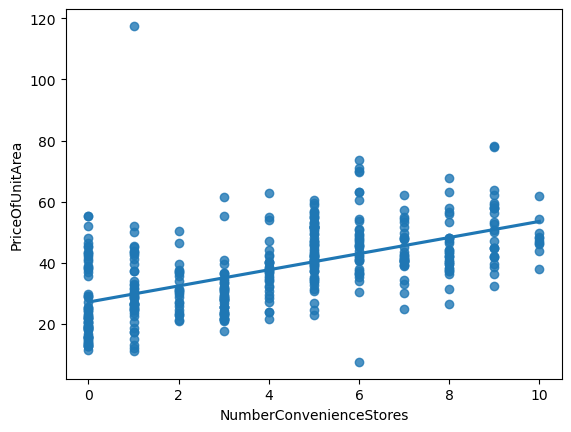

In [9]:
# Create a scatter plot with linear trend line of PriceOfUnitArea vs. NumberConvenienceStores
sns.regplot(x = 'NumberConvenienceStores', y = 'PriceOfUnitArea', data = taiwan_df, ci = None)

# Show the plot
plt.show()

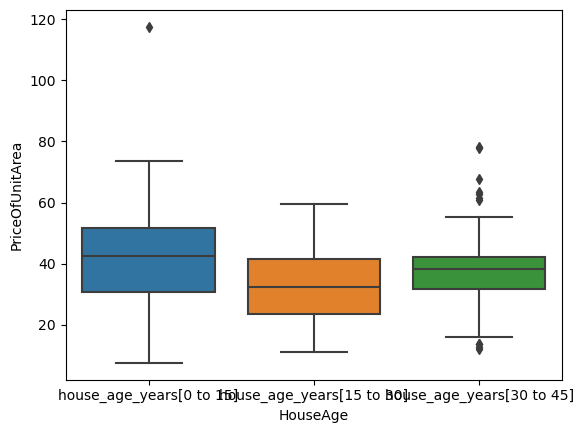

In [10]:
# With a single categorical explanatory variable, the predictions are the means of each category.

# Create a boxplot of price_twd_msq vs. house_age_years
sns.boxplot(x= 'HouseAge', y = 'PriceOfUnitArea', data = taiwan_df)

# Show the plot
plt.show()